In [45]:
import pandas as pd
import numpy as np

from math import radians, sin, cos, sqrt, atan2

In [46]:
# Station Metadata
station_df = pd.read_csv("../data/processed/feature_engineered_ev_dataset_2.csv")

# Demand Profile
demand_df = pd.read_csv("../data/processed/demand_profile.csv")

# Traffic Profile
traffic_profile = pd.read_csv("../data/processed/traffic_profile.csv")

# Area Coordinates
area_df = pd.read_csv("../data/external/area_coordinates.csv")

In [47]:
print(station_df.shape)
print(demand_df.shape)
print(traffic_profile.shape)
print(area_df.shape)

(2089, 61)
(4, 8)
(100, 7)
(25, 3)


In [48]:
station_df.head(2)
station_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 61 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   address                              2089 non-null   str    
 1   latitude                             2089 non-null   float64
 2   longitude                            2089 non-null   float64
 3   staff                                2089 non-null   int64  
 4   postal_code                          2089 non-null   int64  
 5   available                            2089 non-null   float64
 6   capacity                             2089 non-null   float64
 7   cost_per_unit                        2089 non-null   float64
 8   total                                2089 non-null   float64
 9   supports_upi                         2089 non-null   int64  
 10  supports_cash                        2089 non-null   int64  
 11  supports_card                        2089

In [49]:

traffic_profile.head(2)

,Area,time_of_day,trips,avg_density,density_norm,trips_norm,Traffic_Score
0,AIIMS,Afternoon,83,2.168675,0.458258,0.570093,0.491809
1,AIIMS,Evening Peak,120,2.983333,0.876401,0.915888,0.888247


In [50]:
demand_df.head()

,Time_of_Day,sessions,avg_duration,avg_energy,sessions_norm,avg_duration_norm,avg_energy_norm,Demand_Score
0,Afternoon,20,101.900,49.290000,0.666667,0.000000,0.000000,0.200000
1,Evening,16,114.625,67.375000,0.000000,1.000000,1.000000,0.700000
2,Morning,22,105.000,64.495455,1.000000,0.243615,0.840777,0.649679
3,Night,0,0.000,0.000000,0.000000,0.000000,0.000000,0.000000


In [51]:
area_df.head(2)

,Area,Latitude,Longitude
0,Vasant Kunj,28.5245,77.1540
1,Greater Kailash,28.5484,77.2387


In [52]:
station_df["Utilization_Score"] = (
    1 - (station_df["available"] / station_df["total"])
)
station_df["Utilization_Score"].value_counts()

Utilization_Score
0.000000    1972
1.000000      95
0.500000      21
0.333333       1
Name: count, dtype: int64

In [53]:
station_df["total"].value_counts().sort_index()

total
1.0     1919
2.0      121
3.0       29
4.0       10
6.0        2
7.0        2
12.0       3
13.0       1
20.0       1
40.0       1
Name: count, dtype: int64

In [54]:
station_df["available"].value_counts().sort_index()

available
0.0       95
1.0     1876
2.0       89
3.0       11
4.0       10
7.0        2
12.0       3
13.0       1
20.0       1
40.0       1
Name: count, dtype: int64

In [55]:
station_df["Capacity_Norm"] = (
    station_df["capacity"] - station_df["capacity"].min()
) / (
    station_df["capacity"].max() - station_df["capacity"].min()
)
station_df["Capacity_Norm"].value_counts()

Capacity_Norm
0.000000    1732
0.084355     151
1.000000      75
0.134823      37
0.026676      19
0.163663      16
0.047585      16
0.379957      16
0.178082       9
0.048306       8
0.192502       4
0.029560       2
0.120404       1
0.336698       1
0.091565       1
0.408796       1
Name: count, dtype: int64

In [56]:
station_df[["capacity", "Capacity_Norm"]].head(10)

,capacity,Capacity_Norm
0,15.0,0.084355
1,3.3,0.000000
2,15.0,0.084355
3,15.0,0.084355
4,15.0,0.084355
5,3.3,0.000000
6,15.0,0.084355
7,3.3,0.000000
8,3.3,0.000000
9,30.0,0.192502


<Axes: >

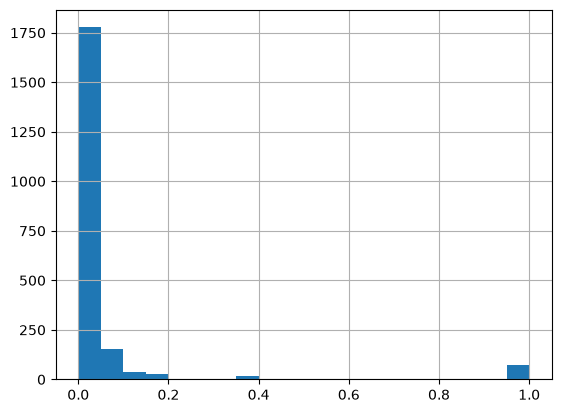

In [57]:
station_df["Capacity_Norm"].hist(bins=20)

In [58]:
station_df["capacity"].value_counts().sort_index()

capacity
3.3      1732
7.0        19
7.4         2
9.9        16
10.0        8
15.0      151
16.0        1
20.0        1
22.0       37
26.0       16
28.0        9
30.0        4
50.0        1
56.0       16
60.0        1
142.0      75
Name: count, dtype: int64